In [79]:
import pandas as pd
import random
import uuid
from datetime import datetime, timezone, timedelta

USERS = [f"U-{i:03d}" for i in range(50)]
CATEGORIES = ['grocery', 'electronics', 'fuel', 'restaurant', 'online_shop', 'atm']
CITIES = ['Warsaw', 'Krakow', 'Gdansk', 'Wroclaw', 'Berlin', 'London']

NORMAL_WEIGHTS = [45, 16, 14, 10, 7, 6] 

def pick_city(is_fraud):
    if is_fraud:
        return random.choices(CITIES, weights=[55, 10, 8, 7, 10, 10])[0]
    return random.choices(CITIES, weights=[42, 18, 14, 10, 10, 6])[0]

def pick_category(is_fraud, city):
    if is_fraud:
        return random.choices(CATEGORIES, weights=[10, 18, 16, 10, 38, 8])[0]
    if city == 'London':
        return random.choices(CATEGORIES, weights=[18, 16, 16, 22, 20, 8])[0]
    if city == 'Berlin':
        return random.choices(CATEGORIES, weights=[22, 18, 18, 18, 16, 8])[0]
    return random.choices(CATEGORIES, weights=NORMAL_WEIGHTS)[0]

def pick_amount(is_fraud, category):
    if is_fraud:
        if category == 'online_shop':
            return round(random.uniform(120, 2500) + random.gauss(0, 180), 2)
        if category == 'atm':
            return round(random.uniform(250, 4500) + random.gauss(0, 260), 2)
        if category == 'fuel':
            return round(random.uniform(80, 1800) + random.gauss(0, 120), 2)
        return round(random.uniform(50, 3200) + random.gauss(0, 220), 2)

    base = {
        'grocery': (15, 450),
        'electronics': (50, 2200),
        'fuel': (30, 260),
        'restaurant': (20, 500),
        'online_shop': (15, 1800),
        'atm': (40, 800),
    }[category]
    amount = random.uniform(*base) + random.gauss(0, (base[1] - base[0]) * 0.08)
    return round(max(1.0, amount), 2)

def make_historical_transaction(simulated_time):
    user_id = random.choice(USERS)
    hour = simulated_time.hour
    is_night = hour >= 23 or hour <= 5

    base_fraud = 0.03
    if is_night:
        base_fraud += 0.03
    if random.random() < 0.12:
        base_fraud += 0.02

    is_fraud = random.random() < base_fraud

    city = pick_city(is_fraud)
    category = pick_category(is_fraud, city)
    amount = pick_amount(is_fraud, category)

    if not is_fraud and random.random() < 0.08:
        amount = round(amount * random.uniform(0.75, 1.25), 2)
    if is_fraud and random.random() < 0.25:
        amount = round(amount * random.uniform(0.55, 1.15), 2)

    return {
        'transaction_id': f"TXN-{uuid.uuid4().hex[:8]}",
        'timestamp': simulated_time.isoformat(),
        'user_id': user_id,
        'amount': amount,
        'currency': 'PLN',
        'merchant_category': category,
        'city': city,
        'is_fraud': is_fraud,
    }

data = []
current_time = datetime.now(timezone.utc) - timedelta(days=30)

for i in range(100000):
    current_time += timedelta(minutes=random.uniform(0.1, 15))
    data.append(make_historical_transaction(current_time))

df_raw = pd.DataFrame(data)
df_raw.to_csv('historical_transactions_v2.csv', index=False)
print(f"Zapisano {len(df_raw)} rekordów.")

Zapisano 100000 rekordów.


Procentowy rozkład klas (is_fraud):
is_fraud
0    95.836
1     4.164
Name: proportion, dtype: float64
------------------------------


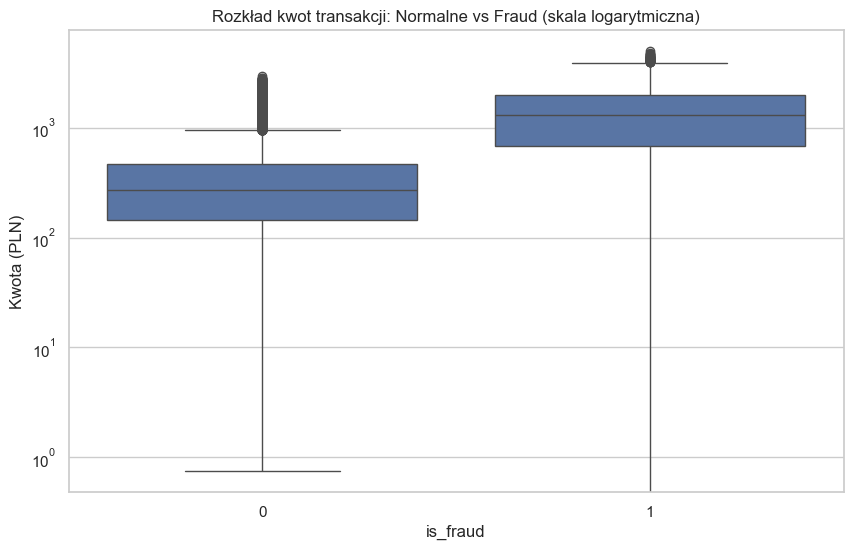

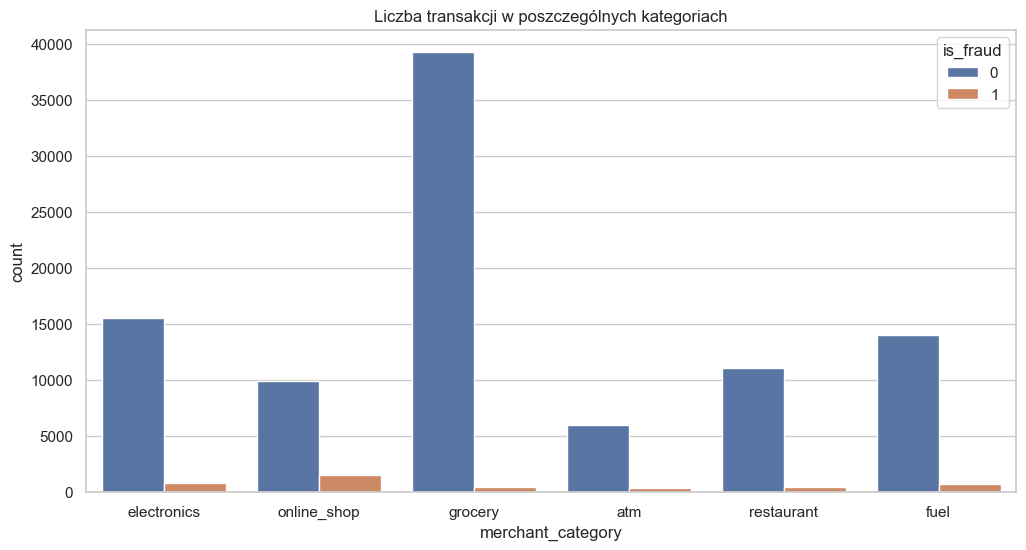


Miasta dla fraudów bankomatowych (powinna być tylko zagranica):
city
Warsaw     186
Berlin      42
Krakow      33
London      31
Wroclaw     26
Gdansk      23
Name: count, dtype: int64


In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('historical_transactions.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

sns.set_theme(style="whitegrid")

# 1. Sprawdzenie balansu klas
print("Procentowy rozkład klas (is_fraud):")
print(df['is_fraud'].value_counts(normalize=True) * 100)
print("-" * 30)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_fraud', y='amount')
plt.yscale('log')
plt.title('Rozkład kwot transakcji: Normalne vs Fraud (skala logarytmiczna)')
plt.ylabel('Kwota (PLN)')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='merchant_category', hue='is_fraud')
plt.title('Liczba transakcji w poszczególnych kategoriach')
plt.show()

# Sprawdzenie miast w przypadku fraudów z bankomatów
fraud_atm = df[(df['is_fraud'] == True) & (df['merchant_category'] == 'atm')]
print("\nMiasta dla fraudów bankomatowych (powinna być tylko zagranica):")
print(fraud_atm['city'].value_counts())

In [81]:
df_features = df_raw.copy()
df_features['timestamp'] = pd.to_datetime(df_features['timestamp'])

df_features['hour'] = df_features['timestamp'].dt.hour

def map_city_group(city):
    if city in ['Berlin', 'London', 'Lagos']:
        return 'zagranica'
    else:
        return 'inne'

columns_to_drop = ['transaction_id', 'timestamp', 'user_id','currency' ]
df_features = df_features.drop(columns=columns_to_drop)

#One-Hot Encoding
df_model = pd.get_dummies(df_features, columns=['merchant_category', 'city'], drop_first=True)
df_model['is_fraud'] = df_model['is_fraud'].astype(int)

print("Kształt danych", df_model.shape)

print(list(df_model.columns))

Kształt danych (100000, 13)
['amount', 'is_fraud', 'hour', 'merchant_category_electronics', 'merchant_category_fuel', 'merchant_category_grocery', 'merchant_category_online_shop', 'merchant_category_restaurant', 'city_Gdansk', 'city_Krakow', 'city_London', 'city_Warsaw', 'city_Wroclaw']


Waga klasy fraud (scale_pos_weight): 24.00
Rozpoczynam tuning modelu. To może chwilę potrwać...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Najlepsze znalezione parametry:
{'subsample': 0.6, 'n_estimators': 75, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

--- Raport Klasyfikacji (Najlepszy Model) ---
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     19200
           1       0.23      0.85      0.36       800

    accuracy                           0.88     20000
   macro avg       0.61      0.86      0.65     20000
weighted avg       0.96      0.88      0.91     20000



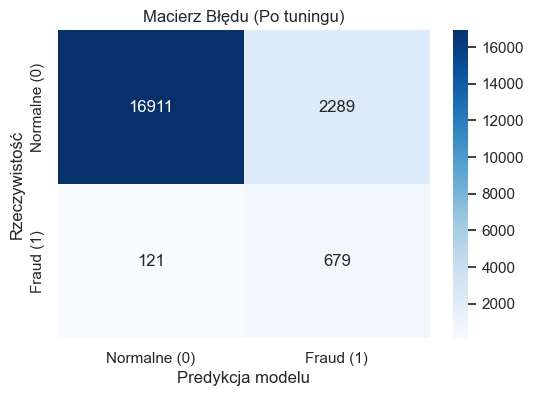

In [82]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X = df_model.drop('is_fraud', axis=1).astype(float)
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Waga klasy fraud (scale_pos_weight): {scale_weight:.2f}")

param_grid = {
    'max_depth': [3, 5, 7],                     
    'learning_rate': [0.01, 0.05, 0.1, 0.2],    
    'n_estimators': [50, 75, 100, 200, 300],            
    'subsample': [0.5, 0.6, 0.7, 0.8, 1.0],               
    'colsample_bytree': [0.7, 0.8, 1.0]        
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=param_grid, 
    n_iter=10, 
    scoring='average_precision', 
    cv=5,         
    verbose=2, 
    random_state=42,
    n_jobs=-1    
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print(random_search.best_params_)

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normalne (0)', 'Fraud (1)'], 
            yticklabels=['Normalne (0)', 'Fraud (1)'])
plt.ylabel('Rzeczywistość')
plt.xlabel('Predykcja modelu')
plt.title('Macierz Błędu (Po tuningu)')
plt.show()

#
best_model.save_model("xgboost_fraud_model_tuned.json")
import json
with open("expected_features.json", "w") as f:
    json.dump(list(X.columns), f)

<Figure size 1200x800 with 0 Axes>

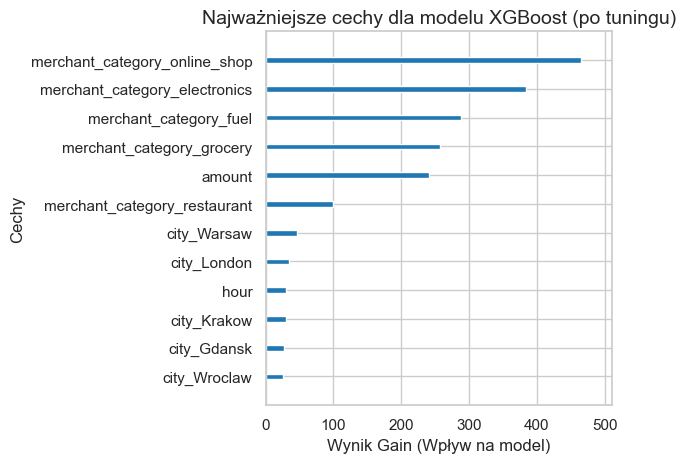

In [83]:
# 9. Wykres ważności cech (Feature Importance) dla najlepszego modelu
plt.figure(figsize=(12, 8))

# Używamy typ='gain', co pokazuje, jak bardzo dana cecha poprawiała trafność predykcji
xgb.plot_importance(
    best_model, 
    max_num_features=16, 
    importance_type='gain', 
    show_values=False,
    color='#1f77b4'
)

plt.title('Najważniejsze cechy dla modelu XGBoost (po tuningu)', fontsize=14)
plt.ylabel('Cechy', fontsize=12)
plt.xlabel('Wynik Gain (Wpływ na model)', fontsize=12)
plt.tight_layout()
plt.show()